In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

import numpy as np

In [2]:
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

### Partie 1 – Analyse exploratoire

1. Décrire la structure du jeu de données.
2. Identifier les variables pertinentes pour la segmentation.
3. Analyser la distribution des variables numériques.
4. Détecter d’éventuelles valeurs aberrantes.
5. Justifier les variables retenues pour le clustering.

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(f"Le jeu de données comprend {df.shape[0]} lignes et {df.shape[1]} colonnes.")
print(f"Les colonnes du jeu de données sont : {df.columns.to_list()}")

Le jeu de données comprend 200 lignes et 5 colonnes.
Les colonnes du jeu de données sont : ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


Remarque : La colonne `CustomerID` n'est pas pertinente pour la clusterisation.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Remarque : Pas de valeur manquante.

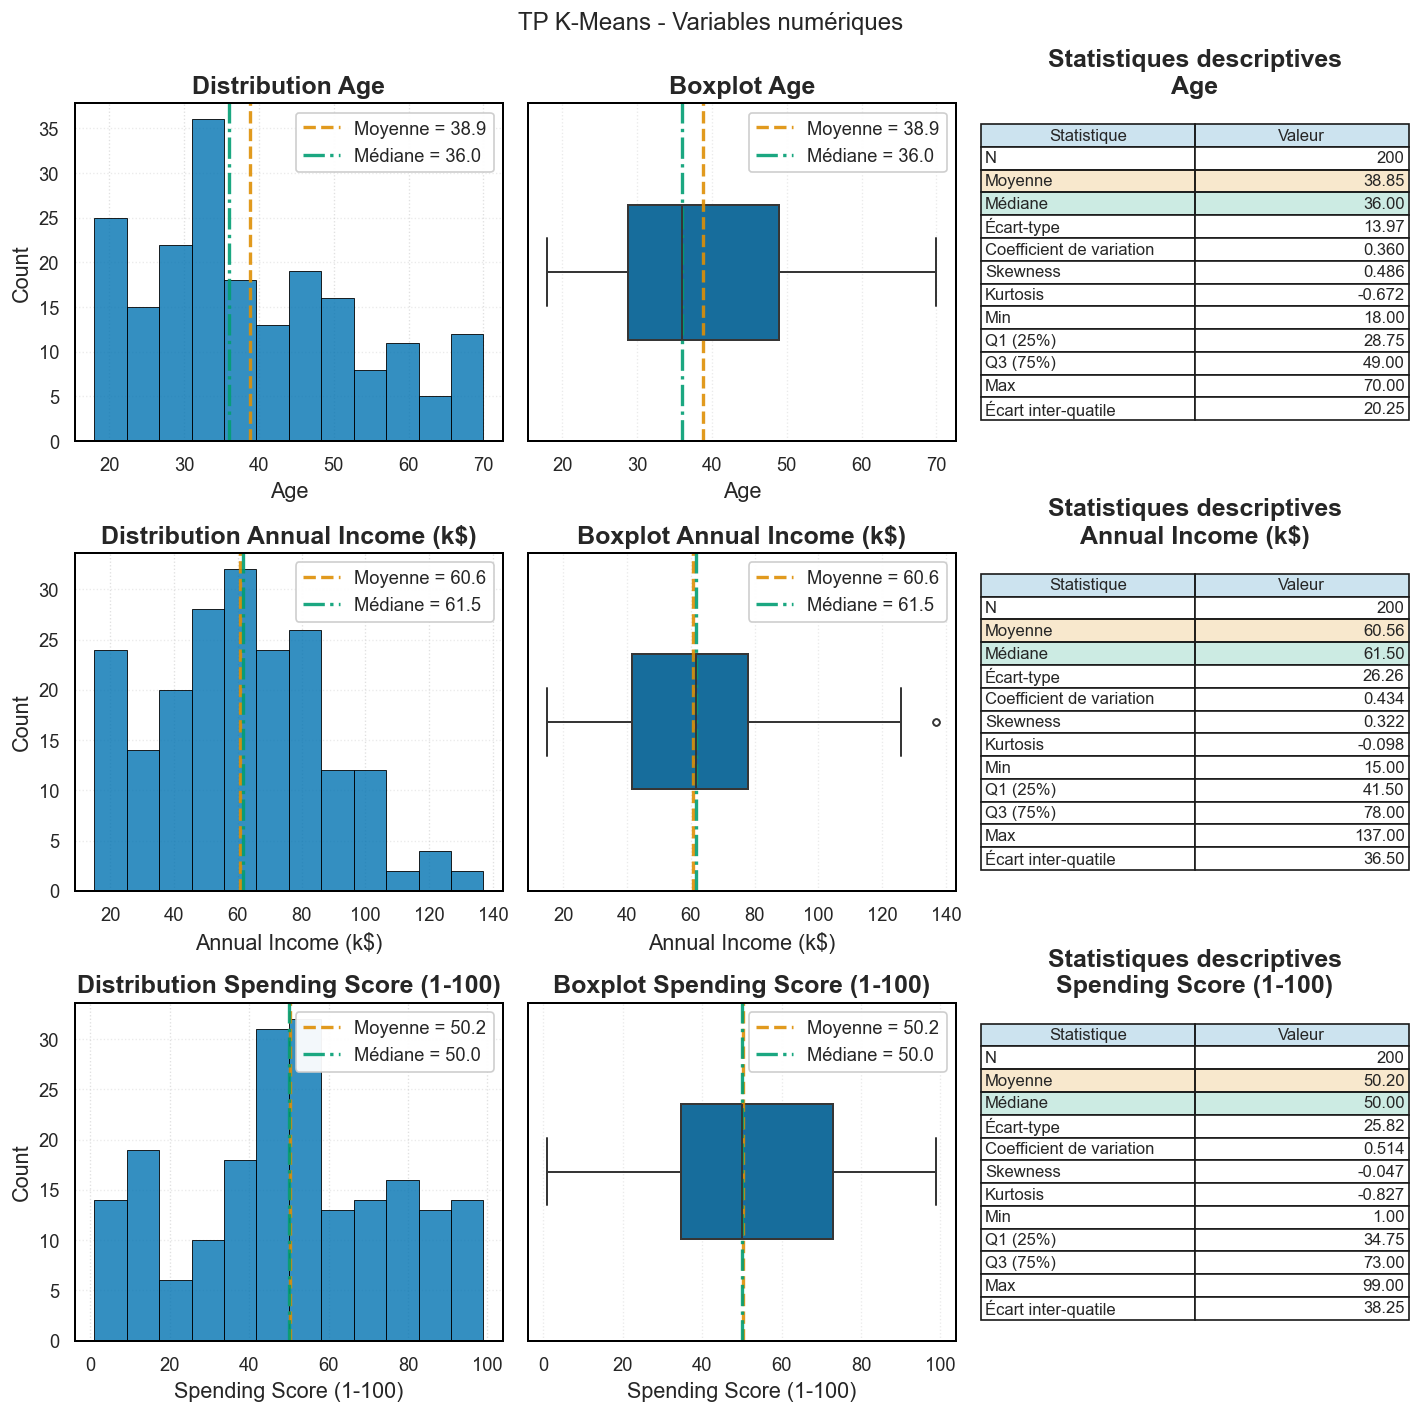

In [18]:
def create_histplot(ax, df, column):
    values = df[column].dropna()

    sns.histplot(
        x=values,
        bins=12,
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, df, column):
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, df, column):
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

fig.suptitle("TP K-Means - Variables numériques")

num_var = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

for k in range(3):
    ax1 = axes[k, 0]
    create_histplot(ax=ax1, df=df, column=num_var[k])
    ax1.set_title(f"Distribution {num_var[k]}")

    ax2 = axes[k, 1]
    create_boxplot(ax2, df, num_var[k])
    ax2.set_title(f"Boxplot {num_var[k]}")

    ax3 = axes[k, 2]
    create_stats_panel(ax3, df, num_var[k])
    ax3.set_title(f"Statistiques descriptives\n{num_var[k]}")

fig.tight_layout()
plt.savefig("tp_kmeans_variables_numeriques.png")
plt.show()

Observations :
- Age
  - Variabilité relative modérée.
  - Légère asymétrie.
  - Distribution homogène.
  - Aplatie.
  - Pas d'outlier détecté avec la méthode de Turkey.
- Annual income
  - Variabilité relative forte.
  - Quasi symétrique.
  - Homogénéité moyenne.
  - Forme quasi normale.
  - 1 outlier détecté avec la méthode de Turkey.
- Spending Score
  - Variabilité relative forte.
  - Symétrique.
  - Distribution hétérogène.
  - Très aplatie.
  - Pas d'outlier détecté avec la méthode de Turkey.

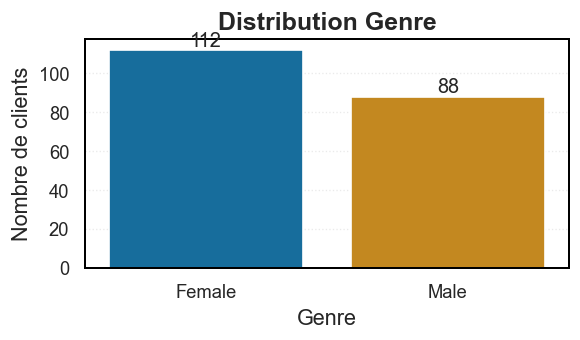

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(5, 3))

churn = df["Genre"].value_counts()

barplot = sns.barplot(
    x=churn.index,
    y=churn.values,
    palette="colorblind",
    hue=churn.index,
    legend=False,
    ax=axes,
)

for container in barplot.containers:
    barplot.bar_label(container)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Distribution Genre")
axes.set_xlabel("Genre")
axes.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

In [8]:
print(
    f"Proportion de 'Female' dans la variable Genre : {churn.loc['Female'] / churn.sum() * 100:.2f}%"
)
print(
    f"Proportion de 'Male' dans la variable Genre : {churn.loc['Male'] / churn.sum() * 100:.2f}%"
)

Proportion de 'Female' dans la variable Genre : 56.00%
Proportion de 'Male' dans la variable Genre : 44.00%


Observation :
- Distribution de la variable Genre modérément déséquilibrée.

### Partie 2 – Préparation des données

1. Sélectionner les variables utilisées pour K-Means.
2. Justifier la nécessité (ou non) de la normalisation.
3. Appliquer une standardisation adaptée.
4. Expliquer mathématiquement pourquoi le scaling est important dans K-Means.

In [9]:
cat_var = [
    # "Genre",
]
num_vars = [
    # "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
]

X = df[cat_var + num_var]

On conserve les variables avec la plus grande coefficient de variation, ie avec la plus grande variabilité.

In [10]:
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_var),
        ("num", num_pipeline, num_vars),
    ]
)

X_transformed = preprocessor.fit_transform(X)

La standardisation est importante pour le modèle KMeans puisque le modèle minimise l'inertie $J$ qui est calculée à partir de la distance euclidienne.
$$J=\sum_{k=1}^{K}\sum_{x_i\in C_k}||x_i-\mu_k||^2$$
Or si une variable a de grandes valeurs et une autre de petites valeurs, la variable avec les petites valeurs n'aura qu'un impact négligeable sur le calcule de l'inertie $J$.
Pour que chaque variable ait le même point dans le calcule de l'inertie, on standardise les variables.

### Partie 3 – Choix du nombre de clusters

1. Appliquer la méthode du coude (Elbow Method).
2. Interpréter la courbe d’inertie.
3. Calculer le score de silhouette pour différents k.
4. Justifier le choix final du nombre de clusters.
5. Discuter les limites de ces méthodes.

In [11]:
k_max = 15

inertia = []
silhouettes = []
for k in range(2, k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    y_pred = kmeans.fit_predict(X_transformed)

    silhouettes.append(silhouette_score(X_transformed, y_pred))

    inertia.append(kmeans.inertia_)

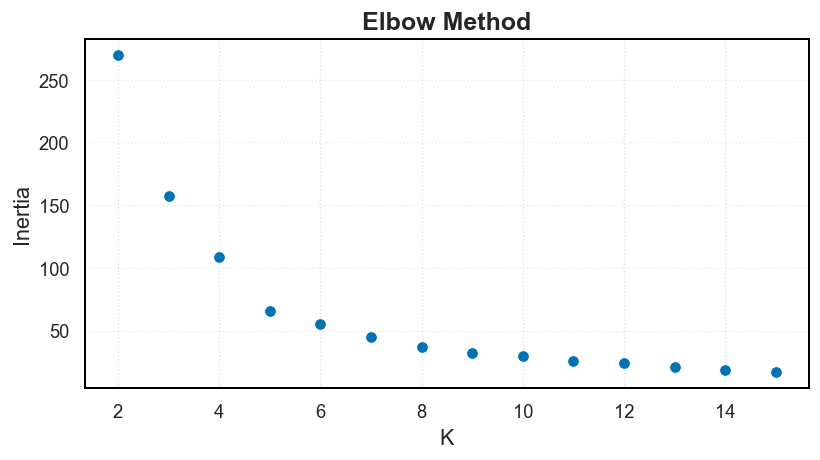

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4))

sns.scatterplot(
    x=range(2, k_max + 1),
    y=inertia,
    ax=axes,
)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Elbow Method")
axes.set_xlabel("K")
axes.set_ylabel("Inertia")

plt.tight_layout()
plt.show()

Le coude semble être aux alentours de K = 5.

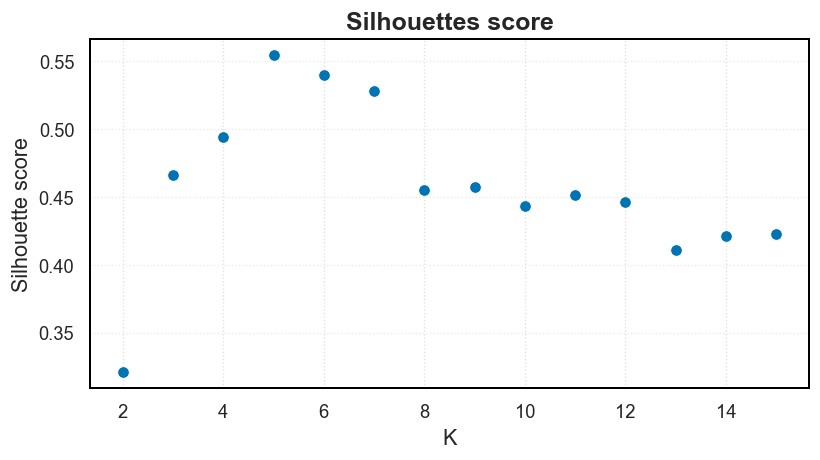

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4))

sns.scatterplot(
    x=range(2, k_max + 1),
    y=silhouettes,
    ax=axes,
)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Silhouettes score")
axes.set_xlabel("K")
axes.set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

La silhouette est maximale pour K = 5.

In [19]:
print(f"Silhouette pour k = 5 : {max(silhouettes)}")

Silhouette pour k = 5 : 0.5546571631111091


### Partie 4 – Clustering avec K-Means

1. Entraîner un modèle K-Means avec le nombre de clusters choisi.
2. Associer chaque client à un cluster.
3. Extraire les centres des clusters.
4. Interpréter la signification des centres dans l’espace des variables.

In [15]:
k_optimal = 5

kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

y_pred_optimal = kmeans_optimal.fit_predict(X_transformed)

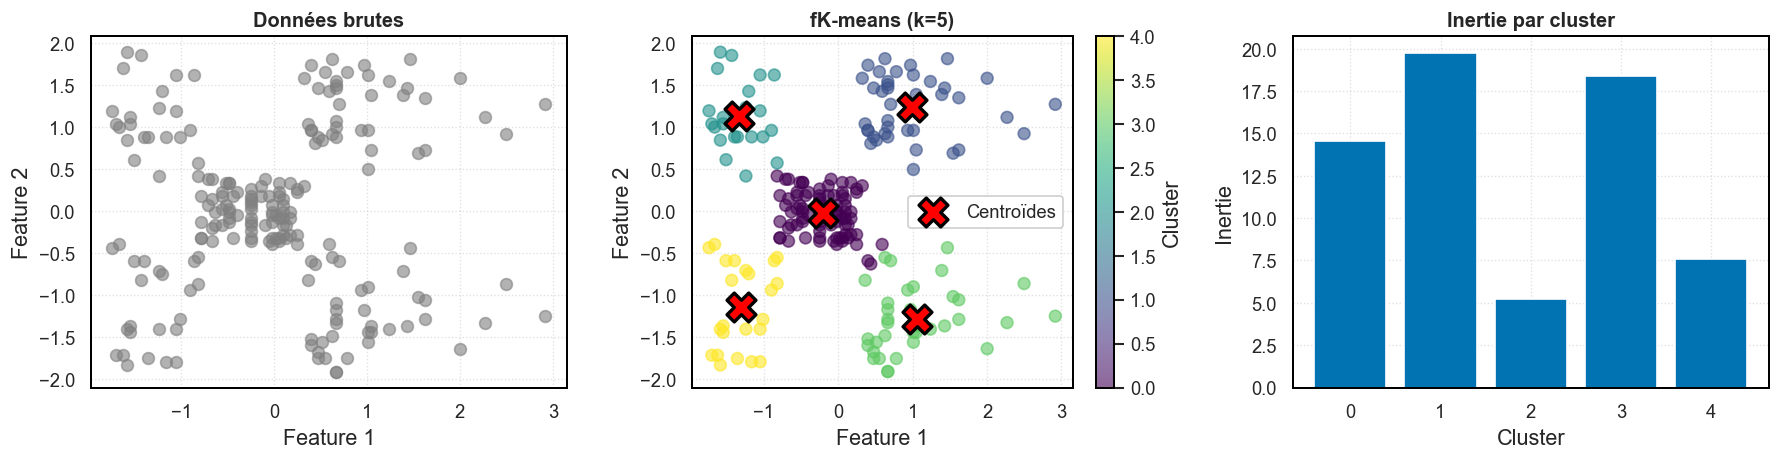

Inertie totale: 65.57


In [16]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Données brutes
axes[0].scatter(X_transformed[:, 0], X_transformed[:, 1], c="gray", alpha=0.6, s=50)
axes[0].set_title("Données brutes", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Clusters prédits
scatter = axes[1].scatter(
    X_transformed[:, 0],
    X_transformed[:, 1],
    c=y_pred_optimal,
    cmap="viridis",
    alpha=0.6,
    s=50,
)
axes[1].scatter(
    kmeans_optimal.cluster_centers_[:, 0],
    kmeans_optimal.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=2,
    label="Centroïdes",
)
axes[1].set_title(f"fK-means (k={k_optimal})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label="Cluster")

# Inertie par cluster
inertia_by_cluster = []
for i in range(k_optimal):
    cluster_points = X_transformed[y_pred_optimal == i]
    center = kmeans_optimal.cluster_centers_[i]
    inertia = np.sum((cluster_points - center) ** 2)
    inertia_by_cluster.append(inertia)

axes[2].bar(range(k_optimal), inertia_by_cluster)
axes[2].set_title("Inertie par cluster", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Inertie")
axes[2].set_xticks(range(k_optimal))

plt.tight_layout()
plt.show()

print(f"Inertie totale: {sum(inertia_by_cluster):.2f}")

Les centroïdes sont proche de l'isobarycentre des points du cluster, on peut l'interpréter comme le représentant moyen du cluster.

### Partie 5 – Analyse métier des segments

Pour chaque cluster :

1. Calculer les moyennes des variables numériques.
2. Identifier le profil type du segment.
3. Donner un nom stratégique au segment (ex : VIP, impulsifs, prudents, etc.).

In [17]:
stats_cluster = {
    "index": [],
    "count": [],
    "nb_female": [],
    "nb_male": [],
    "avg_age": [],
    "std_age": [],
    "avg_annual_income": [],
    "std_annual_income": [],
    "avg_spending_score": [],
    "std_spending_score": [],
}

for i in range(k_optimal):
    X_cluster = df[y_pred_optimal == i]

    stats_cluster["index"].append(i)
    stats_cluster["count"].append(len(X_cluster))
    stats_cluster["nb_female"].append(len(X_cluster[X_cluster["Genre"] == "Female"]))
    stats_cluster["nb_male"].append(len(X_cluster[X_cluster["Genre"] == "Male"]))
    stats_cluster["avg_age"].append(X_cluster["Age"].mean())
    stats_cluster["std_age"].append(X_cluster["Age"].std())
    stats_cluster["avg_annual_income"].append(X_cluster["Annual Income (k$)"].mean())
    stats_cluster["std_annual_income"].append(X_cluster["Annual Income (k$)"].std())
    stats_cluster["avg_spending_score"].append(
        X_cluster["Spending Score (1-100)"].mean()
    )
    stats_cluster["std_spending_score"].append(
        X_cluster["Spending Score (1-100)"].std()
    )

stats_cluster_df = pd.DataFrame(stats_cluster)
stats_cluster_df.head()

,index,count,nb_female,nb_male,avg_age,std_age,avg_annual_income,std_annual_income,avg_spending_score,std_spending_score
0,0,81,48,33,42.716049,16.447822,55.296296,8.988109,49.518519,6.530909
1,1,39,21,18,32.692308,3.728650,86.538462,16.312485,82.128205,9.364489
2,2,22,13,9,25.272727,5.257030,25.727273,7.566731,79.363636,10.504174
3,3,35,16,19,41.114286,11.341676,88.200000,16.399067,17.114286,9.952154
4,4,23,14,9,45.217391,13.228607,26.304348,7.893811,20.913043,13.017167


- Cluster 0 : Income moyen / Score moyen -> target
- Cluster 1 : Income haut / Score haut -> VIP
- Cluster 2 : Income bas / Score haut -> impulsif
- Cluster 3 : Income haut / Score bas -> occasionnel
- Cluster 4 : Income bas / Score bas -> économe

### Partie 6 – Analyse critique

1. Quelles sont les limites de K-Means dans ce contexte ?
2. Que se passe-t-il si on ajoute la variable Age ?
3. Que se passe-t-il si on ajoute Gender ?
4. Quels seraient les avantages d’un modèle probabiliste comme GMM ?
5. Dans quels cas DBSCAN serait-il plus adapté ?

1. K-Means n'est pas adapté aux clusters non convexes, à tendance à homogénéiser la taille des clusters, est sensibles aux outliers $\simeq 65.57$.
2. En ajoutant l'âge, le nombre de cluster optimal devient 6 et l'inertie totale augmente $\simeq 133.87$.
3. En ajoutant le genre, le nombre de cluster optimal devient 11 et l'inertie totale diminue $\simeq 56.81$.